In [1]:
# ==========================================================
# LAB ASSIGNMENT 05
# Sentiment Classification of IMDb Movie Reviews
# Using RNN, LSTM, Bi-LSTM and GRU
# ==========================================================

# Install required libraries
!pip -q install scikit-learn gradio

# Core libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time

# Dataset
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Bidirectional,
    Dense,
    Dropout
)

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
    auc
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("="*50)
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("GPU Available      :", tf.config.list_physical_devices('GPU'))
print("="*50)

TensorFlow Version : 2.20.0
NumPy Version      : 2.1.3
GPU Available      : []


In [2]:
# ==========================================================
# CELL 2 : Load IMDb Dataset & Dataset Constraints
# ==========================================================

VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 100
EMBEDDING_DIM = 128

# Load dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

# Display dataset information
print("="*55)
print("IMDb DATASET SUCCESSFULLY LOADED")
print("="*55)

print(f"Training Samples        : {len(X_train):,}")
print(f"Testing Samples         : {len(X_test):,}")
print(f"Positive Train Reviews  : {np.sum(y_train):,}")
print(f"Negative Train Reviews  : {len(y_train)-np.sum(y_train):,}")

print("\nExperimental Constraints")
print("-"*55)
print(f"Vocabulary Size         : {VOCAB_SIZE}")
print(f"Maximum Sequence Length : {MAX_SEQUENCE_LENGTH}")
print(f"Embedding Dimension     : {EMBEDDING_DIM}")
print(f"Number of Classes       : 2")
print(f"Output                 : Binary Sentiment (0/1)")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
IMDb DATASET SUCCESSFULLY LOADED
Training Samples        : 25,000
Testing Samples         : 25,000
Positive Train Reviews  : 12,500
Negative Train Reviews  : 12,500

Experimental Constraints
-------------------------------------------------------
Vocabulary Size         : 10000
Maximum Sequence Length : 100
Embedding Dimension     : 128
Number of Classes       : 2
Output                 : Binary Sentiment (0/1)


In [3]:
# ==========================================================
# CELL 3 : Decode Reviews & Dataset Exploration
# ==========================================================

# Get word index dictionary
word_index = imdb.get_word_index()

# Reverse dictionary (integer → word)
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

# Function to decode a review
def decode_review(sequence):
    return " ".join([reverse_word_index.get(i, "?") for i in sequence])

# Review length statistics
review_lengths = [len(review) for review in X_train]

print("="*60)
print("REVIEW LENGTH STATISTICS")
print("="*60)
print(f"Minimum Length : {min(review_lengths)} words")
print(f"Maximum Length : {max(review_lengths)} words")
print(f"Mean Length    : {np.mean(review_lengths):.2f} words")
print(f"Median Length  : {np.median(review_lengths):.0f} words")

# Display one positive and one negative review
pos_idx = np.where(y_train == 1)[0][0]
neg_idx = np.where(y_train == 0)[0][0]

print("\n" + "="*60)
print("POSITIVE REVIEW (Sample)")
print("="*60)
print(decode_review(X_train[pos_idx])[:900])

print("\n" + "="*60)
print("NEGATIVE REVIEW (Sample)")
print("="*60)
print(decode_review(X_train[neg_idx])[:900])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
REVIEW LENGTH STATISTICS
Minimum Length : 11 words
Maximum Length : 2494 words
Mean Length    : 238.71 words
Median Length  : 178 words

POSITIVE REVIEW (Sample)
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just b

Positive Reviews : 12500
Negative Reviews : 12500


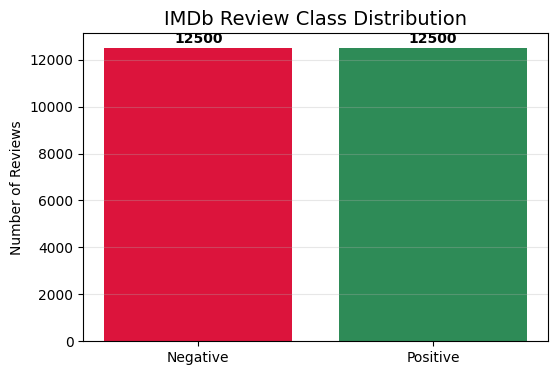

In [4]:
# ==========================================================
# CELL 4 : Class Distribution
# ==========================================================

positive = np.sum(y_train == 1)
negative = np.sum(y_train == 0)

print(f"Positive Reviews : {positive}")
print(f"Negative Reviews : {negative}")

plt.figure(figsize=(6,4))

bars = plt.bar(
    ["Negative", "Positive"],
    [negative, positive],
    color=["crimson", "seagreen"]
)

plt.title("IMDb Review Class Distribution", fontsize=14)
plt.ylabel("Number of Reviews")

# Value labels
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+200,
        f"{int(h)}",
        ha="center",
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)
plt.show()

REVIEW LENGTH STATISTICS
Minimum Length : 11 words
Maximum Length : 2494 words
Mean Length    : 238.71 words
Median Length  : 178 words


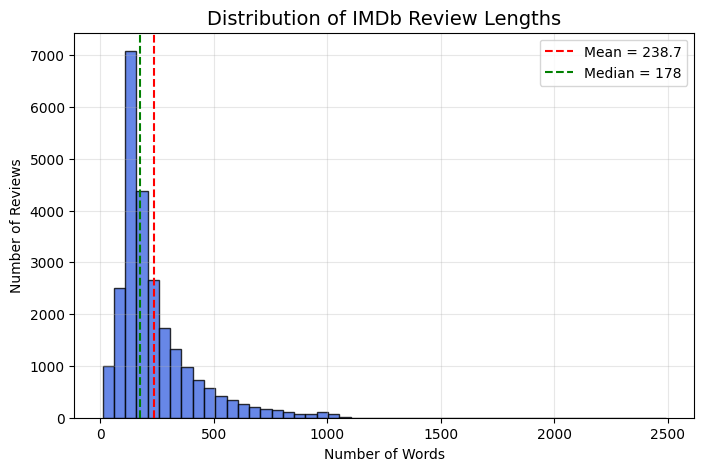

In [5]:
# ==========================================================
# CELL 5 : Review Length Distribution
# ==========================================================

review_lengths = [len(review) for review in X_train]

print("="*55)
print("REVIEW LENGTH STATISTICS")
print("="*55)
print(f"Minimum Length : {np.min(review_lengths)} words")
print(f"Maximum Length : {np.max(review_lengths)} words")
print(f"Mean Length    : {np.mean(review_lengths):.2f} words")
print(f"Median Length  : {np.median(review_lengths):.0f} words")

plt.figure(figsize=(8,5))

plt.hist(
    review_lengths,
    bins=50,
    color="royalblue",
    edgecolor="black",
    alpha=0.8
)

plt.axvline(np.mean(review_lengths), color="red",
            linestyle="--", label=f"Mean = {np.mean(review_lengths):.1f}")

plt.axvline(np.median(review_lengths), color="green",
            linestyle="--", label=f"Median = {np.median(review_lengths):.0f}")

plt.title("Distribution of IMDb Review Lengths", fontsize=14)
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

  Length Range  Number of Reviews
0         < 50                477
1       50–100               2345
2      100–200              11501
3        > 200              10677


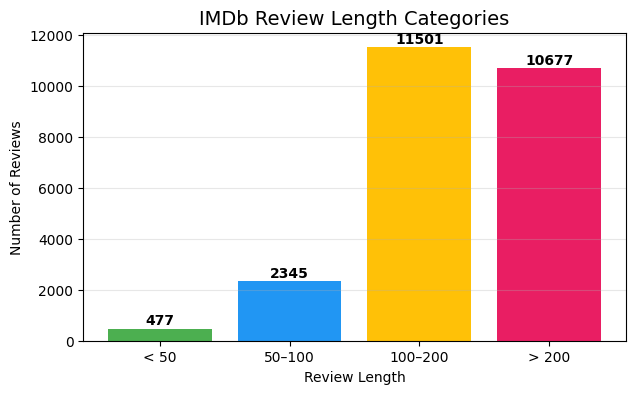

In [6]:
# ==========================================================
# CELL 6 : Sequence Length Category Analysis
# ==========================================================

# Count reviews in each length bucket
less_50 = sum(l < 50 for l in review_lengths)
between_50_100 = sum(50 <= l <= 100 for l in review_lengths)
between_100_200 = sum(101 <= l <= 200 for l in review_lengths)
above_200 = sum(l > 200 for l in review_lengths)

bucket_df = pd.DataFrame({
    "Length Range": ["< 50", "50–100", "100–200", "> 200"],
    "Number of Reviews": [
        less_50,
        between_50_100,
        between_100_200,
        above_200
    ]
})

print(bucket_df)

# Plot
plt.figure(figsize=(7,4))

bars = plt.bar(
    bucket_df["Length Range"],
    bucket_df["Number of Reviews"],
    color=["#4CAF50","#2196F3","#FFC107","#E91E63"]
)

plt.title("IMDb Review Length Categories", fontsize=14)
plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+150,
        f"{int(h)}",
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.show()

In [7]:
# ==========================================================
# CELL 7 : Sequence Padding & Data Split
# ==========================================================

MAX_LEN = 100

# Pad sequences
X_train_pad = pad_sequences(
    X_train,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

# 80:20 validation split
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_pad,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("="*55)
print("PADDED DATASET DIMENSIONS")
print("="*55)
print(f"Training Set   : {X_train_final.shape}")
print(f"Validation Set : {X_val.shape}")
print(f"Testing Set    : {X_test_pad.shape}")

print("\nSample padded sequence (first 20 tokens):")
print(X_train_final[0][:20])

PADDED DATASET DIMENSIONS
Training Set   : (20000, 100)
Validation Set : (5000, 100)
Testing Set    : (25000, 100)

Sample padded sequence (first 20 tokens):
[   1  806    8  135   13   28   57  326   51  363    9  399  252  202
  178  102   40 1354  778  449]


In [8]:
# ==========================================================
# CELL 8 : Simple RNN Model
# ==========================================================

def build_rnn():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE,
                  output_dim=128,
                  input_length=MAX_LEN),

        SimpleRNN(64),

        Dropout(0.5),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

rnn_model = build_rnn()

# Build model and display summary
rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ==========================================================
# CELL 9 : LSTM Model
# ==========================================================

def build_lstm():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE,
                  output_dim=128,
                  input_length=MAX_LEN),

        LSTM(64),

        Dropout(0.5),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

lstm_model = build_lstm()

# Display summary
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# ==========================================================
# CELL 10 : Bidirectional LSTM Model
# ==========================================================

def build_bilstm():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE,
                  output_dim=128,
                  input_length=MAX_LEN),

        Bidirectional(LSTM(64)),

        Dropout(0.5),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

bilstm_model = build_bilstm()

# Display model summary
bilstm_model.build(input_shape=(None, MAX_LEN))
bilstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,378,945 (5.26 MB)

 Trainable params: 1,378,945 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# ==========================================================
# CELL 11 : GRU Model
# ==========================================================

def build_gru():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE,
                  output_dim=128,
                  input_length=MAX_LEN),

        GRU(64),

        Dropout(0.5),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

gru_model = build_gru()

# Display summary
gru_model.build(input_shape=(None, MAX_LEN))
gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,313 (5.03 MB)

 Trainable params: 1,317,313 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ==========================================================
# CELL 12 : Train All Models
# ==========================================================

EPOCHS = 5
BATCH_SIZE = 128

models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "Bi-LSTM": bilstm_model,
    "GRU": gru_model
}

histories = {}
training_times = {}

for name, model in models.items():

    print("\n" + "="*60)
    print(f"Training {name}")
    print("="*60)

    start = time.time()

    history = model.fit(
        X_train_final,
        y_train_final,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    end = time.time()

    histories[name] = history
    training_times[name] = end - start

print("\nTraining Completed Successfully!")


Training RNN
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 99ms/step - accuracy: 0.6141 - loss: 0.6460 - val_accuracy: 0.7402 - val_loss: 0.5406
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.8069 - loss: 0.4516 - val_accuracy: 0.7706 - val_loss: 0.4968
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 93ms/step - accuracy: 0.8586 - loss: 0.3472 - val_accuracy: 0.7488 - val_loss: 0.5948
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 117ms/step - accuracy: 0.9179 - loss: 0.2279 - val_accuracy: 0.7768 - val_loss: 0.6313
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 189ms/step - accuracy: 0.9474 - loss: 0.1593 - val_accuracy: 0.7470 - val_loss: 0.7257

Training LSTM
Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 51s 312ms/step - accuracy: 0.7066 - loss: 0.5566 - val_accuracy: 0.8174 - val_loss: 0.4290
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 283ms/step - accuracy: 0.8367 - loss: 0.4075 - val_accuracy: 0.8210 - val_loss: 0.4282
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 234ms/step - accuracy

In [13]:
# ==========================================================
# CELL 13 : Training Summary
# ==========================================================

summary = []

for name in models.keys():

    h = histories[name].history

    summary.append([
        name,
        models[name].count_params(),
        round(training_times[name],2),
        round(training_times[name]/EPOCHS,2),
        round(h["loss"][-1],4),
        round(h["val_loss"][-1],4),
        round(h["accuracy"][-1],4),
        round(h["val_accuracy"][-1],4)
    ])

summary_df = pd.DataFrame(summary, columns=[
    "Model",
    "Parameters",
    "Training Time (s)",
    "Avg Epoch Time",
    "Train Loss",
    "Val Loss",
    "Train Accuracy",
    "Val Accuracy"
])

summary_df

,Model,Parameters,Training Time (s),Avg Epoch Time,Train Loss,Val Loss,Train Accuracy,Val Accuracy
0,RNN,1292417,120.19,24.04,0.1593,0.7257,0.9474,0.7470
1,LSTM,1329473,214.28,42.86,0.2187,0.4780,0.9254,0.8040
2,Bi-LSTM,1378945,352.33,70.47,0.2017,0.5492,0.9228,0.8086
3,GRU,1317313,251.12,50.22,0.1923,0.5193,0.9286,0.8190


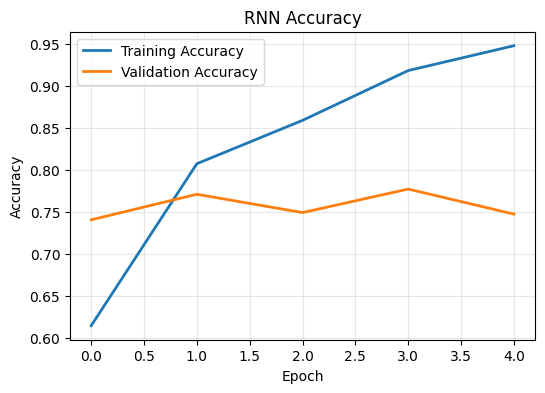

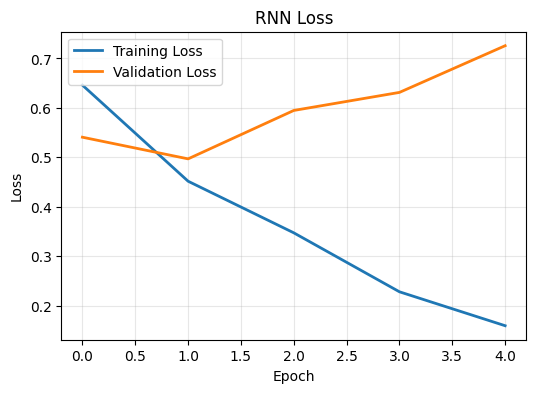

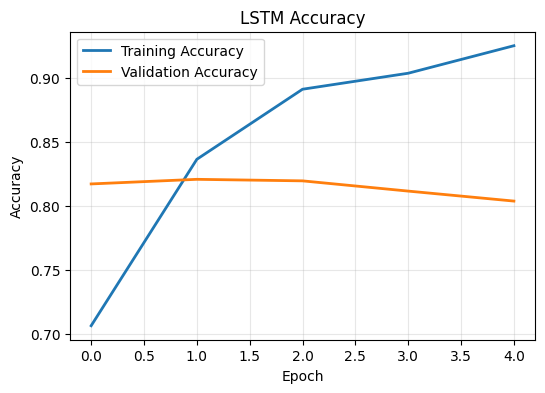

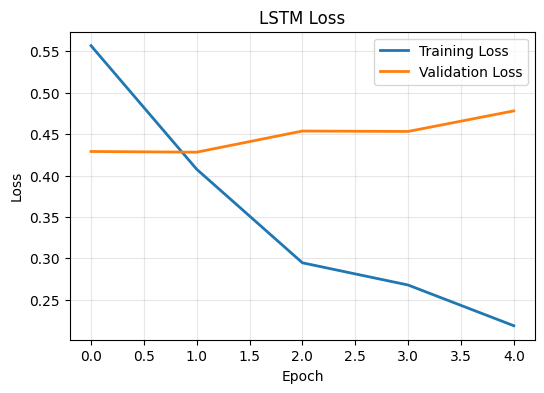

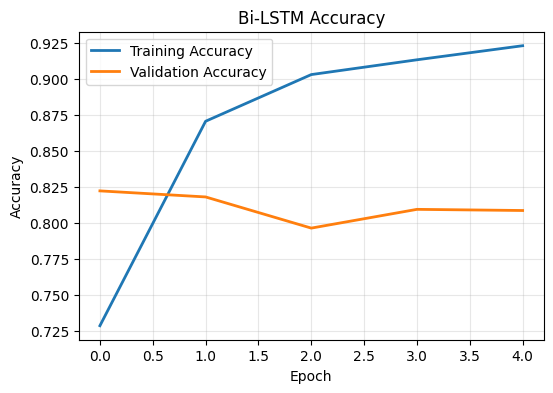

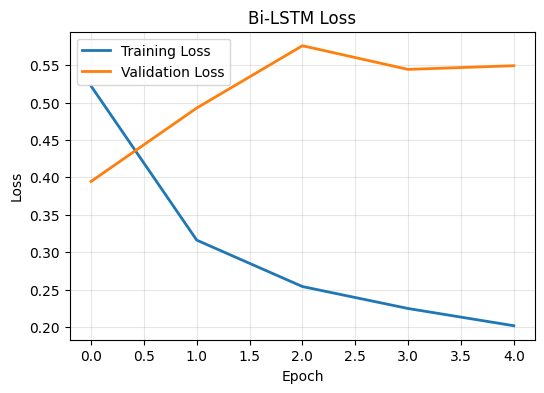

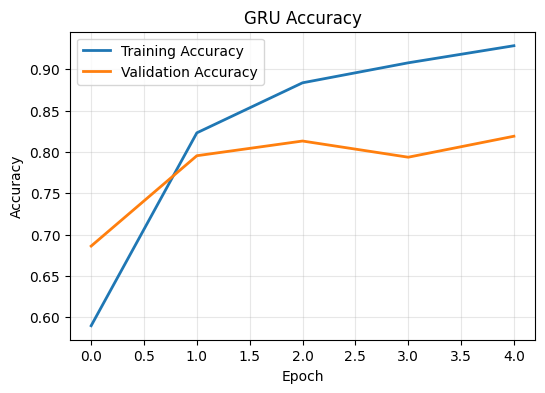

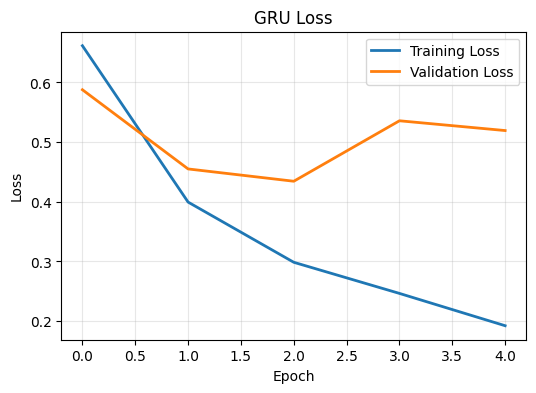

In [14]:
# ==========================================================
# CELL 14 : Training & Validation Curves
# ==========================================================

for name, history in histories.items():

    # Accuracy Plot
    plt.figure(figsize=(6,4))
    plt.plot(history.history['accuracy'], linewidth=2, label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], linewidth=2, label='Validation Accuracy')
    plt.title(f'{name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Loss Plot
    plt.figure(figsize=(6,4))
    plt.plot(history.history['loss'], linewidth=2, label='Training Loss')
    plt.plot(history.history['val_loss'], linewidth=2, label='Validation Loss')
    plt.title(f'{name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [15]:
# ==========================================================
# CELL 15 : Complete Model Evaluation
# ==========================================================

results = []
predictions = {}

for name, model in models.items():

    # Probability predictions
    y_prob = model.predict(X_test_pad, verbose=0).ravel()

    # Binary predictions
    y_pred = (y_prob >= 0.5).astype(int)

    predictions[name] = (y_pred, y_prob)

    # Confusion Matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    specificity = tn / (tn + fp)

    # Precision-Recall AUC
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Specificity": specificity,
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Kappa": cohen_kappa_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": pr_auc,
        "LogLoss": log_loss(y_test, y_prob),
        "Brier": brier_score_loss(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

# Round values for display
results_df = results_df.round(4)

print("="*95)
print("FINAL PERFORMANCE COMPARISON")
print("="*95)

results_df

FINAL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1,Specificity,MCC,Kappa,ROC_AUC,PR_AUC,LogLoss,Brier
0,RNN,0.7400,0.7039,0.8285,0.7611,0.6515,0.4877,0.4800,0.7848,0.7321,0.7482,0.2080
1,LSTM,0.7883,0.7830,0.7976,0.7902,0.7790,0.5767,0.5766,0.8622,0.8557,0.5110,0.1589
2,Bi-LSTM,0.7943,0.7871,0.8067,0.7968,0.7818,0.5887,0.5886,0.8721,0.8641,0.5870,0.1617
3,GRU,0.8018,0.8099,0.7886,0.7991,0.8149,0.6037,0.6035,0.8809,0.8746,0.5674,0.1589


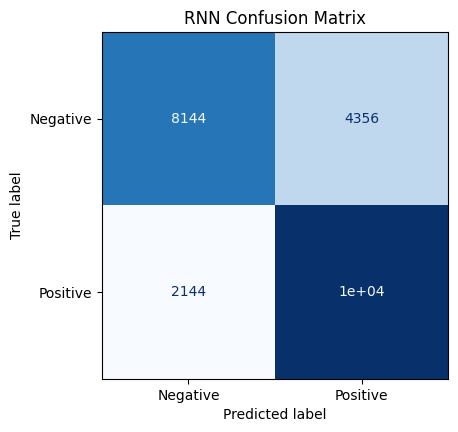

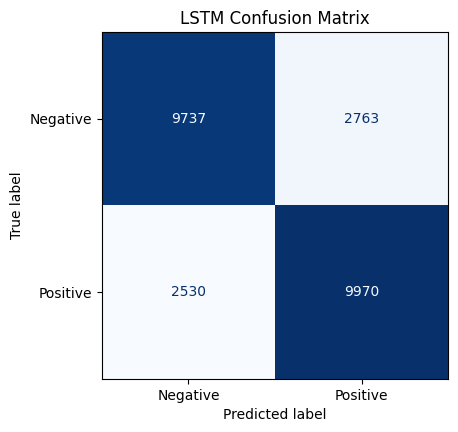

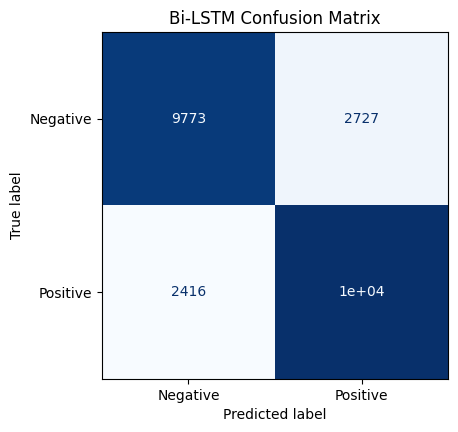

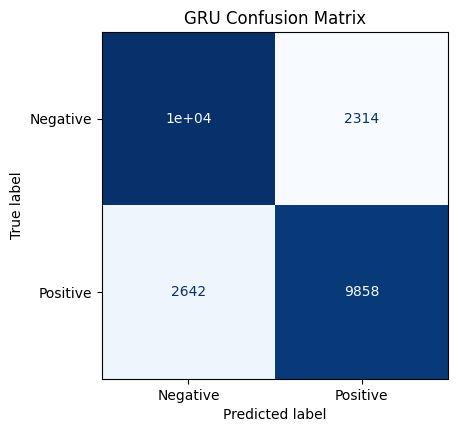

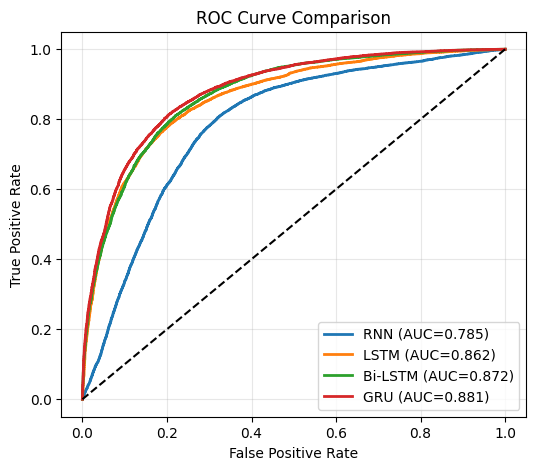

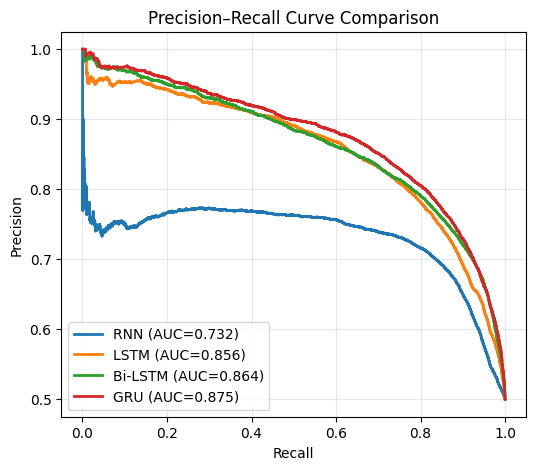

In [16]:
# ==========================================================
# CELL 16 : Confusion Matrix + ROC + PR Curves
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay

# ---------- Confusion Matrices ----------
for name in models.keys():

    y_pred, y_prob = predictions[name]

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative","Positive"]
    )

    fig, ax = plt.subplots(figsize=(4.5,4.5))
    disp.plot(cmap="Blues", ax=ax, colorbar=False)
    plt.title(f"{name} Confusion Matrix")
    plt.show()


# ---------- ROC Curve ----------
plt.figure(figsize=(6,5))

for name in models.keys():

    y_pred, y_prob = predictions[name]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, linewidth=2,
             label=f"{name} (AUC={roc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ---------- Precision–Recall Curve ----------
plt.figure(figsize=(6,5))

for name in models.keys():

    y_pred, y_prob = predictions[name]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, linewidth=2,
             label=f"{name} (AUC={pr_auc:.3f})")

plt.title("Precision–Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

COMPUTATIONAL ANALYSIS


,Model,Parameters,Training Time (s),Inference Time (s)
0,RNN,1292417,120.19,6.964
1,LSTM,1329473,214.28,15.616
2,Bi-LSTM,1378945,352.33,41.052
3,GRU,1317313,251.12,20.542


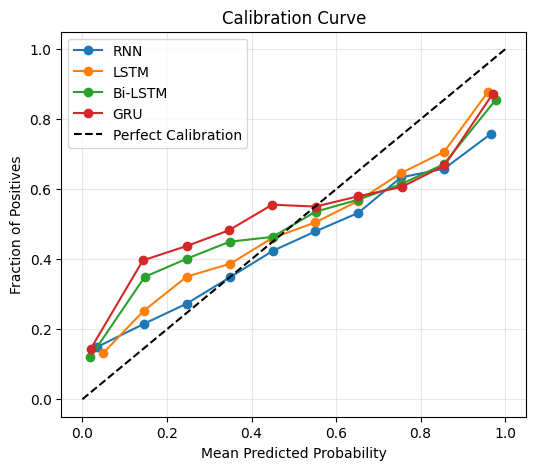

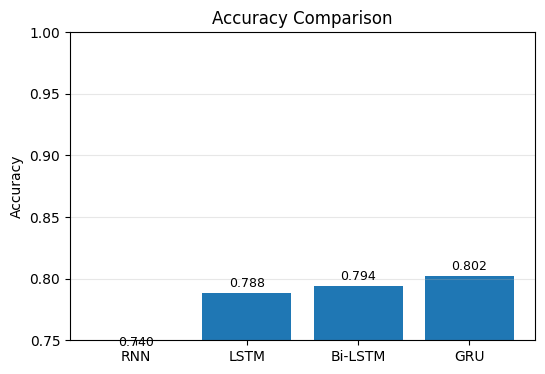

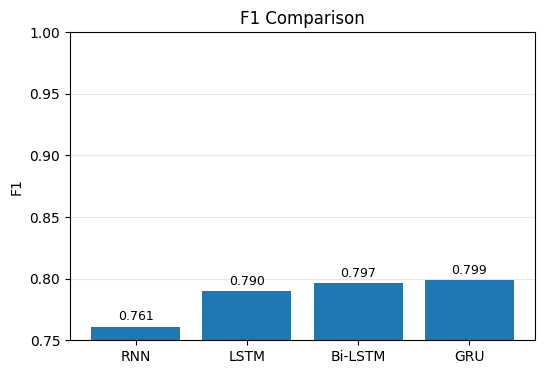

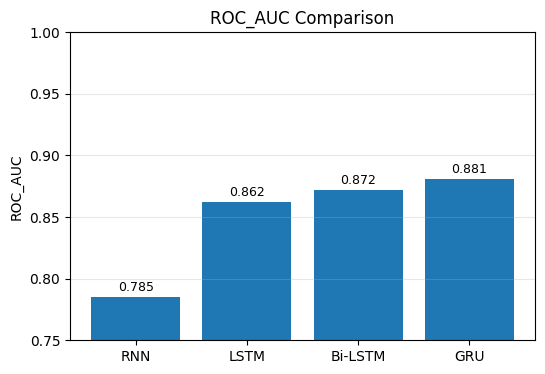

In [17]:
# ==========================================================
# CELL 17 : Calibration + Computational Analysis
# ==========================================================

from sklearn.calibration import calibration_curve

# ---------- Inference Time ----------
inference_times = {}

for name, model in models.items():
    start = time.time()
    _ = model.predict(X_test_pad, verbose=0)
    end = time.time()
    inference_times[name] = end - start

# ---------- Computational Table ----------
comp_df = pd.DataFrame({
    "Model": list(models.keys()),
    "Parameters": [models[m].count_params() for m in models.keys()],
    "Training Time (s)": [round(training_times[m],2) for m in models.keys()],
    "Inference Time (s)": [round(inference_times[m],3) for m in models.keys()]
})

print("="*70)
print("COMPUTATIONAL ANALYSIS")
print("="*70)
display(comp_df)

# ---------- Calibration Curve ----------
plt.figure(figsize=(6,5))

for name in models.keys():
    y_pred, y_prob = predictions[name]

    frac_pos, mean_pred = calibration_curve(
        y_test,
        y_prob,
        n_bins=10
    )

    plt.plot(mean_pred, frac_pos, marker='o', label=name)

plt.plot([0,1],[0,1],'k--',label='Perfect Calibration')
plt.title("Calibration Curve")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ---------- Comparison Bar Charts ----------
metrics = ["Accuracy","F1","ROC_AUC"]

for metric in metrics:

    plt.figure(figsize=(6,4))

    plt.bar(
        results_df["Model"],
        results_df[metric]
    )

    plt.ylim(0.75,1.0)
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)

    for i,v in enumerate(results_df[metric]):
        plt.text(i,v+0.005,f"{v:.3f}",ha='center',fontsize=9)

    plt.grid(axis='y',alpha=0.3)
    plt.show()

In [18]:
# ==========================================================
# CELL 18 : Error Analysis + Save Best Model
# ==========================================================

# Best model based on highest Accuracy
best_model_name = results_df.loc[
    results_df["Accuracy"].idxmax(), "Model"
]

best_model = models[best_model_name]

print("="*60)
print(f"BEST PERFORMING MODEL : {best_model_name}")
print("="*60)

# Get predictions
y_pred, y_prob = predictions[best_model_name]

# False Positives & False Negatives
fp_idx = np.where((y_test==0) & (y_pred==1))[0][:5]
fn_idx = np.where((y_test==1) & (y_pred==0))[0][:5]

# Decode reviews
word_index = imdb.get_word_index()
reverse_word_index = {v+3:k for k,v in word_index.items()}
reverse_word_index[0]="<PAD>"
reverse_word_index[1]="<START>"
reverse_word_index[2]="<UNK>"
reverse_word_index[3]="<UNUSED>"

def decode_review(seq):
    return " ".join(reverse_word_index.get(i,"?") for i in seq)

print("\n========== FALSE POSITIVES ==========")
for i, idx in enumerate(fp_idx,1):
    print(f"\nFP-{i}")
    print(decode_review(X_test[idx])[:350])
    print("-"*50)

print("\n========== FALSE NEGATIVES ==========")
for i, idx in enumerate(fn_idx,1):
    print(f"\nFN-{i}")
    print(decode_review(X_test[idx])[:350])
    print("-"*50)

# Save model
best_model.save("best_imdb_sentiment_model.keras")

print("\nModel saved successfully as:")
print("best_imdb_sentiment_model.keras")

BEST PERFORMING MODEL : GRU

========== FALSE POSITIVES ==========

FP-1
<START> the <UNK> richard <UNK> dog is <UNK> to <UNK> joan fontaine dog however when <UNK> bing crosby arrives in town to sell a record player to the emperor his dog is attacked by <UNK> dog after a revenge attack where <UNK> is <UNK> from town a <UNK> insists that <UNK> dog must confront dog so that she can overcome her <UNK> fears this is arrange
--------------------------------------------------

FP-2
<START> hollywood had a long love affair with bogus <UNK> nights tales but few of these products have stood the test of time the most memorable were the jon hall maria <UNK> films which have long since become camp this one is filled with dubbed songs <UNK> <UNK> and slapstick it's a truly crop of corn and pretty near <UNK> today it was nominated fo
--------------------------------------------------

FP-3
<START> i started watching this because i thought it was a really <UNK> porno as i kept watching the only thril

In [19]:
# ==========================================================
# CELL 19 : Gradio Deployment
# ==========================================================

import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb

# Load IMDb word index
word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = [1]  # <START>

    for word in words:
        idx = word_index.get(word, 2)
        if idx + 3 < 10000:
            encoded.append(idx + 3)
        else:
            encoded.append(2)

    padded = pad_sequences(
        [encoded],
        maxlen=100,
        padding="post",
        truncating="post"
    )

    return padded

def predict_sentiment(review):

    seq = encode_review(review)

    prob = float(best_model.predict(seq, verbose=0)[0][0])

    if prob >= 0.5:
        sentiment = "Positive 😊"
        confidence = prob
    else:
        sentiment = "Negative 😞"
        confidence = 1 - prob

    return (
        sentiment,
        f"{confidence*100:.2f}%"
    )

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=8,
        placeholder="Type a movie review here..."
    ),
    outputs=[
        gr.Textbox(label="Predicted Sentiment"),
        gr.Textbox(label="Confidence")
    ],
    title="IMDb Movie Review Sentiment Classifier",
    description="RNN • LSTM • Bi-LSTM • GRU | Deep Learning NLP Project",
    theme=gr.themes.Soft()
)

demo.launch()

/usr/local/lib/python3.13/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://550647a552fa1f0c62.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
